Time series working

Need to add:
soil profile functionality + f string functionality

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd
import os
import matplotlib.cm as cm

In [2]:
vari = "soil_temp"
ctsm_vari = "TSOI"
site = "BC"

In [3]:
#load ctsm data

ctsm_file = f"..\\CTSM_data\\run_1\\merged_files\\{site}_1995-2014.nc"
df = xr.open_dataset(ctsm_file, engine="netcdf4")
var_ds = df[f"{ctsm_vari}"]

C:\Users\madel\AppData\Local\Temp\ipykernel_28484\4061546363.py:4: FutureWarning: In a future version, xarray will not decode the variable 'SNOW_PERSISTENCE' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  df = xr.open_dataset(ctsm_file, engine="netcdf4")


## Load Obs data

In [4]:
#load observational data

ds_obs = xr.open_dataset(f"../Observational_data/{site}_obs/processed/{vari}/{site}_{vari}.nc")

FileNotFoundError: [Errno 2] No such file or directory: 'c:\\Users\\madel\\Code\\GeoNorth\\Observational_data\\BC_obs\\processed\\soil_temp\\BC_soil_temp.nc'

## Interpolation

defining the interpolation function here

In [ ]:
# only for soil temp. Needs to be moved to utils

def interpolate_to_depth(ds, target_depths, depth_dim="levgrnd", var="TSOI"):
    sm = ds[var].squeeze()
    depths = ds[depth_dim].values.flatten()
    time = ds.indexes['time']
    
    values = []

    for x in target_depths:
        target_depth = x.values

        # Interpolate
        idx = int(np.searchsorted(depths, target_depth, side="right") - 1)
        idx = int(np.clip(idx, 0, len(depths) - 2))
        z0, z1 = depths[idx], depths[idx + 1]
        w = (target_depth - z0) / (z1 - z0)
        sm_interp = ((1 - w) * sm.values[:, idx] + w * sm.values[:, idx + 1]).flatten()
        values.append(sm_interp)

    interpolated_np = np.column_stack(values)


    interpolated_ds = xr.Dataset(
    {f"{var}": (["time", "depth"], interpolated_np, {"units": "K"})},
    coords={
        "time":  time,
        "depth": target_depths.values,
    },
    attrs={"site": "BC", "source": "GWF observed"}
    )

    # Convert K → °C
    interpolated_ds = interpolated_ds - 273.15

    return interpolated_ds



In [ ]:
# interpolate ctsm data to observational data depths

interpolated_ds = interpolate_to_depth(df, ds_obs.depth)

## Plotting

defining the plotting funtion for it to be run a few times

In [ ]:
# needs to be standardized and added to utils

def final_plot(obs, sim, site, depths):
    # Resample observational data to daily frequency
    obs_daily = obs.resample(time="1D").mean()

    for x in depths:
        plt.figure(figsize=(14,6))

        # Observed (daily)
        plt.plot(
            obs_daily["time"].values,
            obs_daily.sel(depth=x.values)["soil_temp"].values,
            label="Observed Soil Temperature (C)",
            linewidth=2
        )

        # Simulated
        plt.plot(
            sim["time"].values,
            sim.sel(depth=x.values)["TSOI"].values,
            label="Simulated Soil Temperature (C)",
            linewidth=2
        )

        plt.xlabel("Time")
        plt.ylabel("Soil Temperature (C)")
        plt.title(f"Soil Temperature at Baker Creek - {x.values*100}cm")
        plt.grid(True)
        plt.legend()
        plt.savefig(f"v1.0_final_images/{site}_soil_temperature_{x.values*100}.png")
        #plt.show()

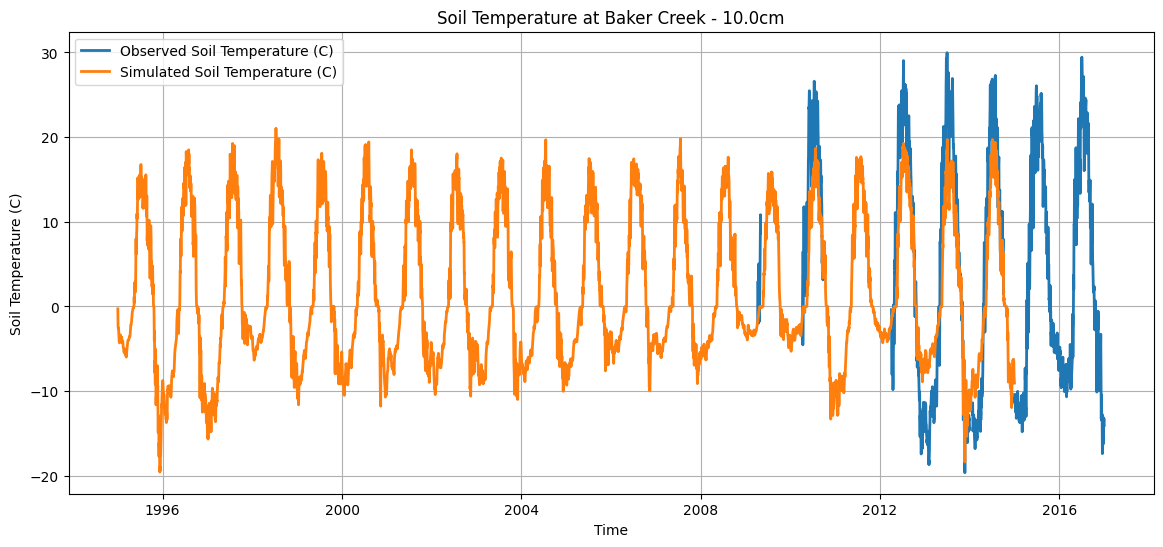

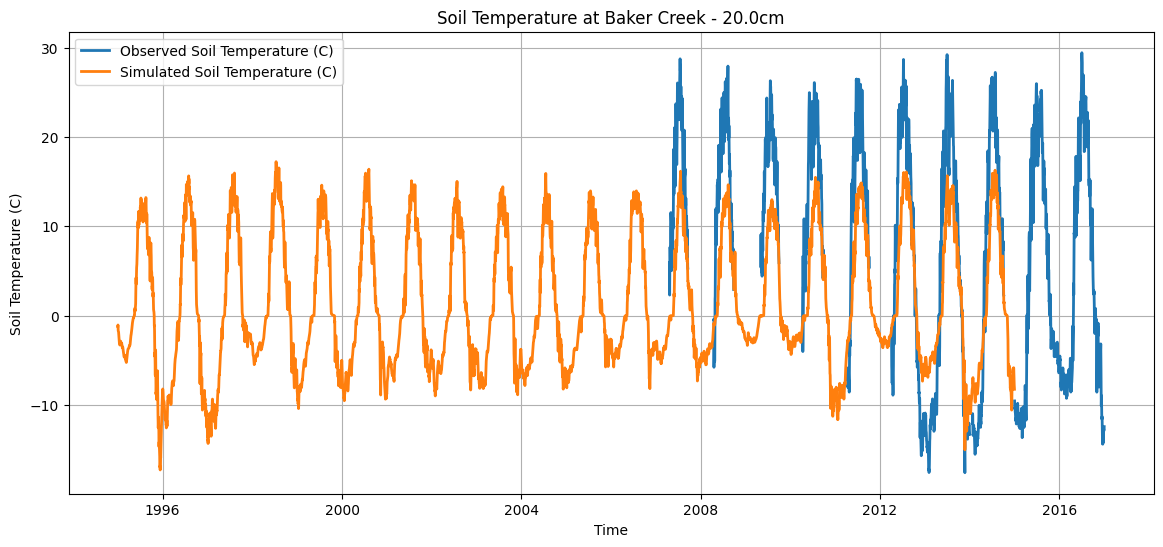

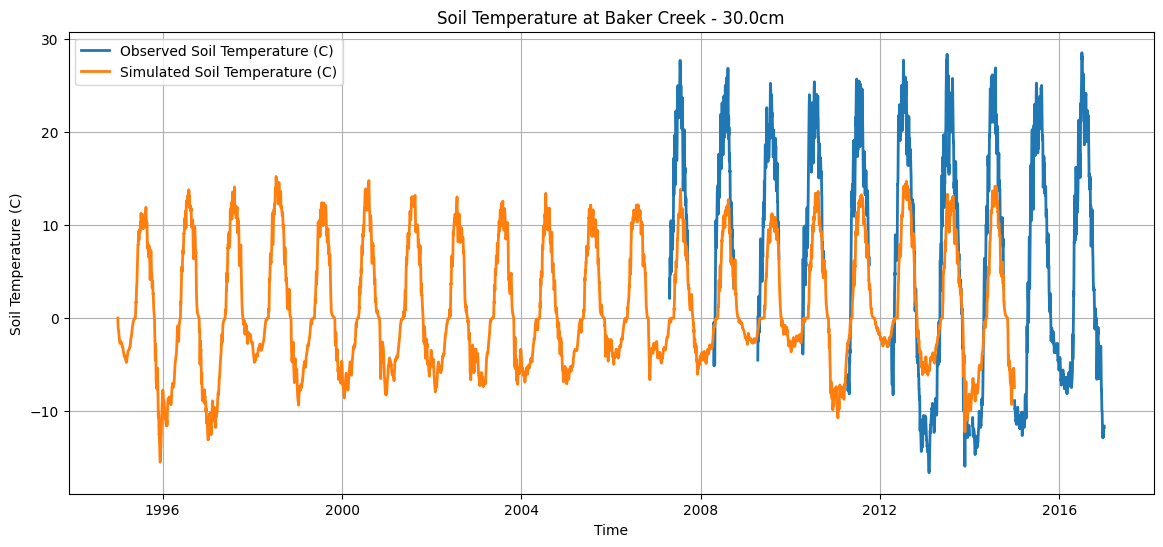

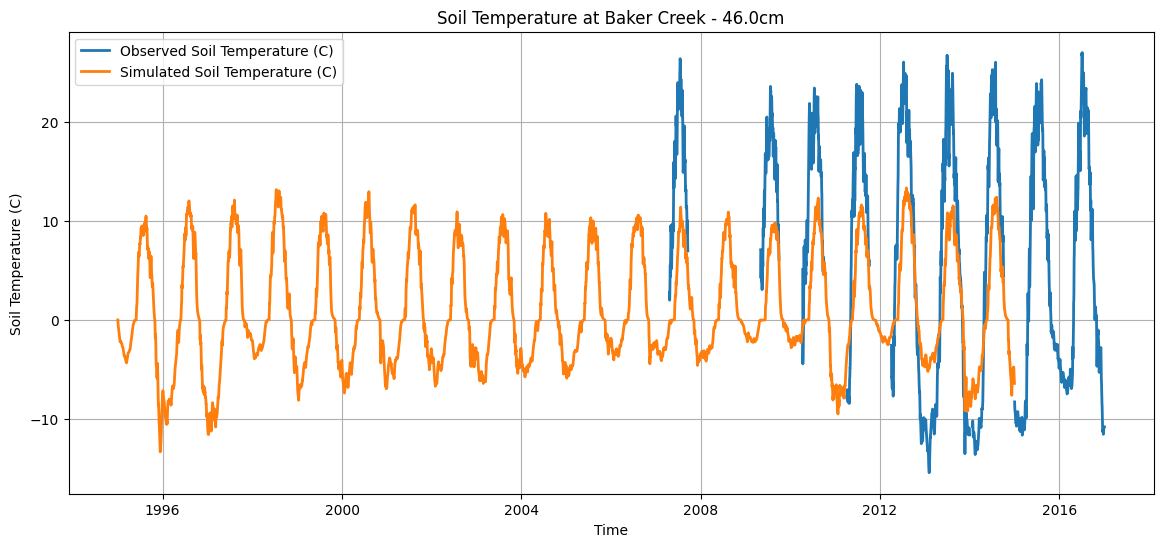

In [ ]:
final_plot(ds_obs, interpolated_ds, f"{site}", ds_obs.depth)

## Soil Temperature Profiles for August

In [ ]:
def plot_soil_profiles(obs, ctsm, site, depths):
        #cut them down to the same time
        t_min = obs.time.values.min()
        t_max = obs.time.values.max()
        ds_ctsm = ctsm.sel(time=slice(t_min, t_max))



        aug_ctsm = ctsm.sel(time=ctsm["time"].dt.month == 8)  # all Augusts across 20 years
        print(f"August timesteps: {len(aug_ctsm.time)}")
        aug_obs = obs.sel(time=obs["time"].dt.month == 8)  # all Augusts across 20 years
        print(f"August timesteps: {len(aug_obs.time)}")
        df["time"].min()

        # # --- Mask CTSM by depth ---
        # depths = np.array(depths)
        # depth_mask      = (depths >= 0) & (depths <= 15)
        # depths_masked   = depths[depth_mask]

        # # --- Mask CTSM by time ---
        # ctsm_times = pd.to_datetime(aug_ctsm["time"].values).tz_localize(None)
        # time_min   = time_min.tz_localize(None) if time_min.tzinfo else time_min
        # time_max   = time_max.tz_localize(None) if time_max.tzinfo else time_max

        # time_mask     = (ctsm_times >= time_min) & (ctsm_times <= time_max)
        # aug_ctsm_masked = aug_ctsm.isel(time=time_mask)

        # # --- Compute CTSM mean/std over masked time, then mask depth ---
        # aug_mean = aug_ctsm_masked.mean(dim="time").values[depth_mask]
        # aug_std  = aug_ctsm_masked.std(dim="time").values[depth_mask]

        # # --- Plot ---
        # fig, ax = plt.subplots(figsize=(6, 6))

        # # CTSM
        # ax.plot(aug_mean, depths_masked,
        #         color="tomato", linewidth=2, label="CTSM Mean")
        # # ax.fill_betweenx(depths_masked,
        # #                  aug_mean - aug_std,
        # #                  aug_mean + aug_std,
        # #                  alpha=0.3, color="tomato", label="CTSM ±1 std")

        # # Observed
        # ax.plot(obs_df["mean_temp"], obs_df["depth_m"],
        #         color="steelblue", linewidth=2, marker="o", label="Observed Mean")
        # # ax.fill_betweenx(obs_df["depth_m"],
        # #                  obs_df["mean_temp"] - obs_df["std_temp"],
        # #                  obs_df["mean_temp"] + obs_df["std_temp"],
        # #                  alpha=0.3, color="steelblue", label="Obs ±1 std")

        # ax.set_xlabel("Soil Temperature (°C)")
        # ax.set_ylabel("Depth (m)")
        # ax.set_title("August Soil Temperature Profile at Baker Creek")
        # ax.set_ylim(0, depth_max)
        # ax.set_xlim(-2,20)
        # ax.axvline(0, color="black", linewidth=0.9, linestyle="--", alpha=0.35, zorder=2)
        # ax.invert_yaxis()
        # ax.legend(loc = "upper left")
        # plt.tight_layout()
        # plt.savefig(f"0_final_images/BC_soil_temp_profile.png")
        # plt.show()


In [ ]:
plot_soil_profiles(ds_obs, interpolated_ds, f"{site}", ds_obs.depth)

TypeError: '>' not supported between instances of 'int' and 'cftime._cftime.DatetimeNoLeap'

August timesteps: 620


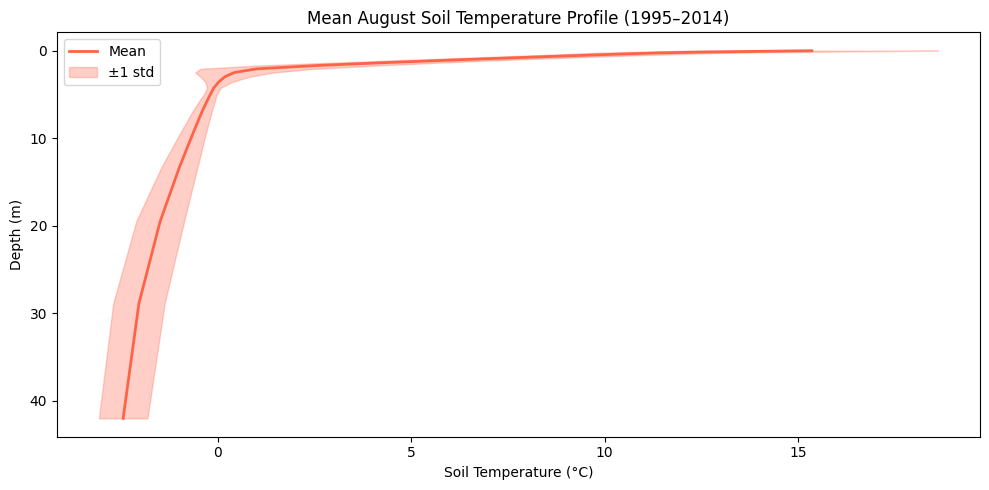

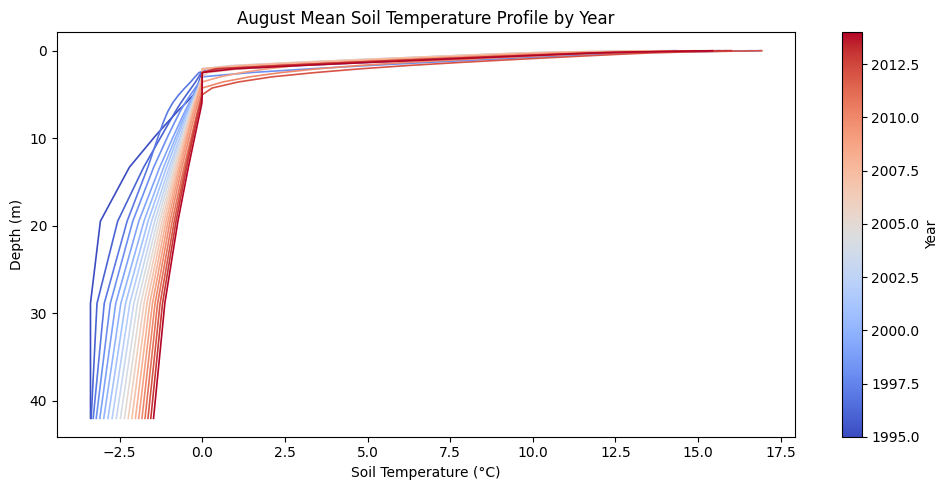

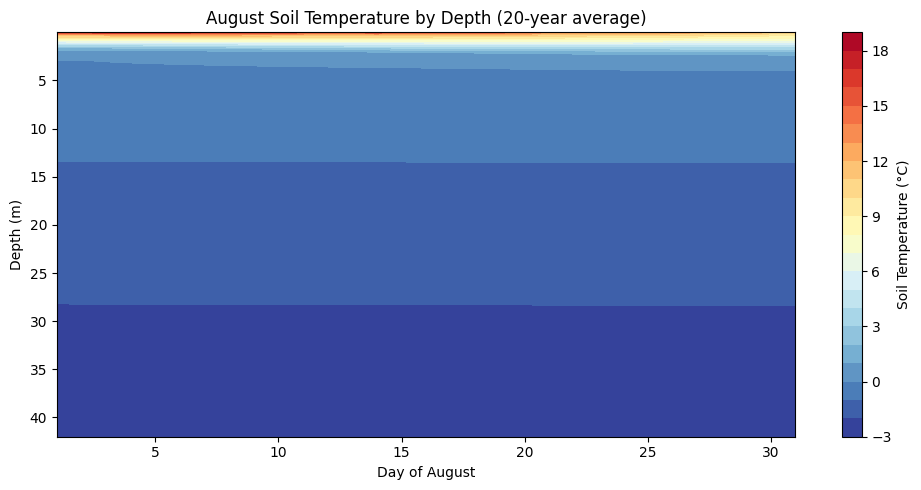

In [ ]:
# Filter to August only
da_aug = interpolated_ds.sel(time=interpolated_ds["time"].dt.month == 8)  # all Augusts across 20 years
print(f"August timesteps: {len(da_aug.time)}")

# --- Plot 1: Mean August soil temperature profile ---
aug_mean = da_aug.mean(dim="time")
aug_std  = da_aug.std(dim="time")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(aug_mean.values, depths, color="tomato", linewidth=2, label="Mean")
ax.fill_betweenx(
    depths,
    aug_mean.values - aug_std.values,
    aug_mean.values + aug_std.values,
    alpha=0.3, color="tomato", label="±1 std"
)
ax.set_xlabel("Soil Temperature (°C)")
ax.set_ylabel("Depth (m)")
ax.set_title("Mean August Soil Temperature Profile (1995–2014)")
ax.invert_yaxis()   # surface at top
ax.legend()
plt.tight_layout()
plt.show()

# --- Plot 2: Individual August profiles, one line per year ---
years = np.unique(da_aug["time"].dt.year.values)
cmap  = cm.coolwarm(np.linspace(0, 1, len(years)))

fig, ax = plt.subplots(figsize=(10, 5))
for i, year in enumerate(years):
    aug_year = da_aug.sel(time=da_aug["time"].dt.year == year).mean(dim="time")
    ax.plot(aug_year.values, depths, color=cmap[i], linewidth=1.2, label=str(year))

ax.set_xlabel("Soil Temperature (°C)")
ax.set_ylabel("Depth (m)")
ax.set_title("August Mean Soil Temperature Profile by Year")
ax.invert_yaxis()
sm_cbar = plt.cm.ScalarMappable(cmap="coolwarm",
                                 norm=plt.Normalize(years.min(), years.max()))
plt.colorbar(sm_cbar, ax=ax, label="Year")
plt.tight_layout()
plt.show()

# --- Plot 3: Heatmap — depth vs day-of-August, averaged across all years ---
da_aug_copy = da_aug.assign_coords(doy=("time", da_aug["time"].dt.day.values))
aug_by_day  = da_aug_copy.groupby("doy").mean()   # mean across all 20 Augusts per day

fig, ax = plt.subplots(figsize=(10, 5))
c = ax.contourf(
    aug_by_day["doy"].values,
    depths,
    aug_by_day.values.T,
    levels=25, cmap="RdYlBu_r"
)
plt.colorbar(c, ax=ax, label="Soil Temperature (°C)")
ax.set_xlabel("Day of August")
ax.set_ylabel("Depth (m)")
ax.set_title("August Soil Temperature by Depth (20-year average)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_august_soil_temp_profile(obs_files: dict, da_aug, depths):
    """
    Plot mean August soil temperature profile comparing observations vs CTSM output.

    Parameters
    ----------
    obs_files : dict
        Keys are filenames like 'TVC_soil_temp_50.txt', values are DataFrames
        with columns [time, temp_c] (first col = time, second = temp).
    da_aug : xarray.DataArray
        CTSM August soil temperature data with dim 'time'.
    depths : array-like
        Depth values (in meters) for the CTSM soil layers.
    """

    # --- Parse observed data ---
    obs_records = []

    for filename, df in obs_files.items():
        depth_cm = float(filename.replace("BC_soil_temp_", "").replace(".txt", ""))
        depth_m = depth_cm / 100.0

        df = df.copy()
        df.columns = ["time", "temp_c"]
        df["time"] = pd.to_datetime(df["time"])

        aug_df = df[df["time"].dt.month == 8]

        if aug_df.empty:
            print(f"Warning: no August data found in {filename}")
            continue

        obs_records.append({
            "depth_m":   depth_m,
            "mean_temp": aug_df["temp_c"].mean(),
            "std_temp":  aug_df["temp_c"].std(),
            "time_min":  df["time"].min(),
            "time_max":  df["time"].max(),
        })

    obs_df = pd.DataFrame(obs_records).sort_values("depth_m").reset_index(drop=True)

    # --- Compute obs depth and time range ---
    depth_min = obs_df["depth_m"].min() - 0.2
    depth_max = obs_df["depth_m"].max() + 0.5
    time_min  = obs_df["time_min"].min()
    time_max  = obs_df["time_max"].max()

    print(f"Restricting CTSM to depths {depth_min}–{depth_max} m "
          f"and time {time_min.date()}–{time_max.date()}")

    # --- Mask CTSM by depth ---
    depths = np.array(depths)
    depth_mask      = (depths >= depth_min) & (depths <= depth_max)
    depths_masked   = depths[depth_mask]

    # --- Mask CTSM by time ---
    ctsm_times = pd.to_datetime(da_aug["time"].values).tz_localize(None)
    time_min   = time_min.tz_localize(None) if time_min.tzinfo else time_min
    time_max   = time_max.tz_localize(None) if time_max.tzinfo else time_max

    time_mask     = (ctsm_times >= time_min) & (ctsm_times <= time_max)
    da_aug_masked = da_aug.isel(time=time_mask)

    # --- Compute CTSM mean/std over masked time, then mask depth ---
    aug_mean = da_aug_masked.mean(dim="time").values[depth_mask]
    aug_std  = da_aug_masked.std(dim="time").values[depth_mask]

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(6, 6))

    # CTSM
    ax.plot(aug_mean, depths_masked,
            color="tomato", linewidth=2, label="CTSM Mean")
    # ax.fill_betweenx(depths_masked,
    #                  aug_mean - aug_std,
    #                  aug_mean + aug_std,
    #                  alpha=0.3, color="tomato", label="CTSM ±1 std")

    # Observed
    ax.plot(obs_df["mean_temp"], obs_df["depth_m"],
            color="steelblue", linewidth=2, marker="o", label="Observed Mean")
    # ax.fill_betweenx(obs_df["depth_m"],
    #                  obs_df["mean_temp"] - obs_df["std_temp"],
    #                  obs_df["mean_temp"] + obs_df["std_temp"],
    #                  alpha=0.3, color="steelblue", label="Obs ±1 std")

    ax.set_xlabel("Soil Temperature (°C)")
    ax.set_ylabel("Depth (m)")
    ax.set_title("August Soil Temperature Profile at Baker Creek")
    ax.set_ylim(0, depth_max)
    ax.set_xlim(-2,20)
    ax.axvline(0, color="black", linewidth=0.9, linestyle="--", alpha=0.35, zorder=2)
    ax.invert_yaxis()
    ax.legend(loc = "upper left")
    plt.tight_layout()
    plt.savefig(f"0_final_images/BC_soil_temp_profile.png")
    plt.show()

Restricting CTSM to depths -0.1–0.96 m and time 2007-04-22–2016-12-31


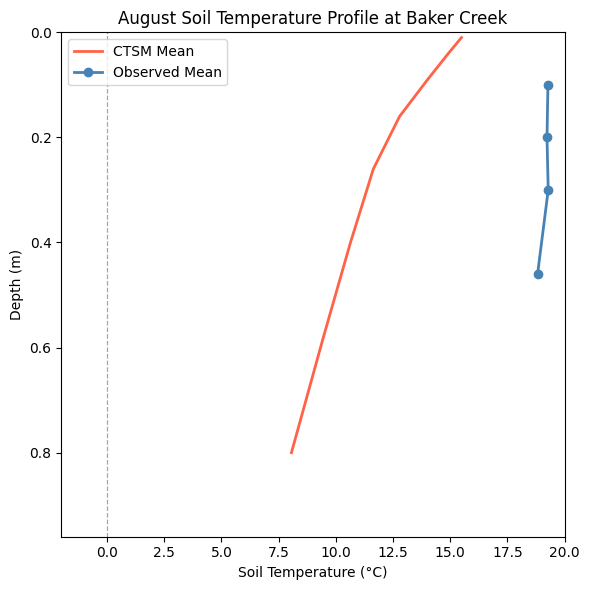

In [ ]:
plot_august_soil_temp_profile(observe, da_aug, depths)